### 1. Data Understanding and Preprocessing


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import itertools
import warnings

# For preprocessing
from sklearn.preprocessing import MinMaxScaler

# For models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.metrics import mean_absolute_percentage_error as mape_func

# ACF
from statsmodels.graphics.tsaplots import plot_acf

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input,
    Conv1D, Bidirectional, Flatten,
    Multiply, Permute, RepeatVector, Lambda,
    Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# Ignore warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv("energy_data_set.csv")  
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [7]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Describe
print(df.describe()) 

Shape: (19735, 29)

Columns:
 Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='str')

Data Types:
 date               str
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            flo

In [8]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(df['date'].dtype)

df.head()

datetime64[us]


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


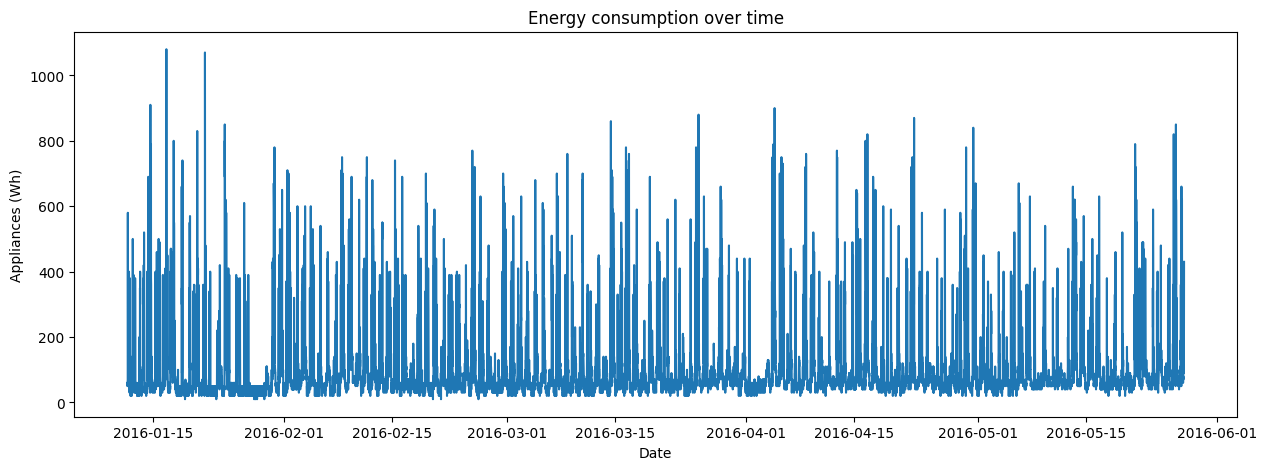

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['Appliances'])
plt.title("Energy consumption over time")
plt.xlabel("Date")
plt.ylabel("Appliances (Wh)")
plt.show()

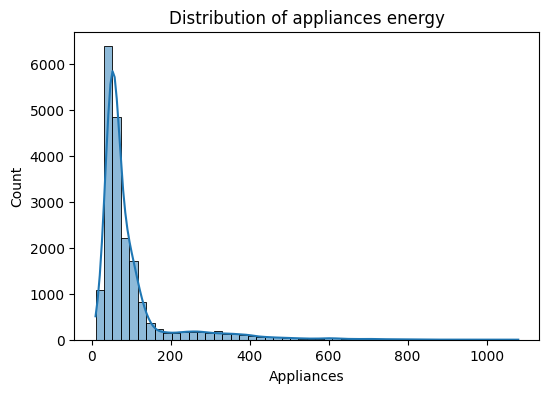

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title("Distribution of appliances energy")
plt.show()

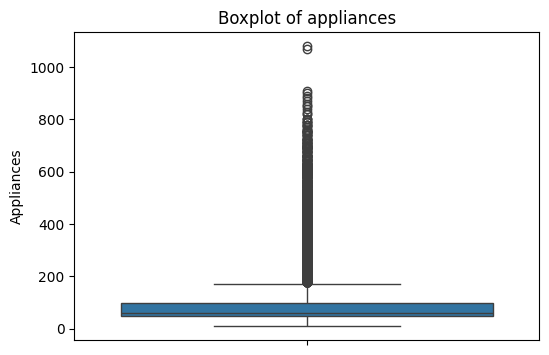

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Appliances'])
plt.title("Boxplot of appliances")
plt.show()

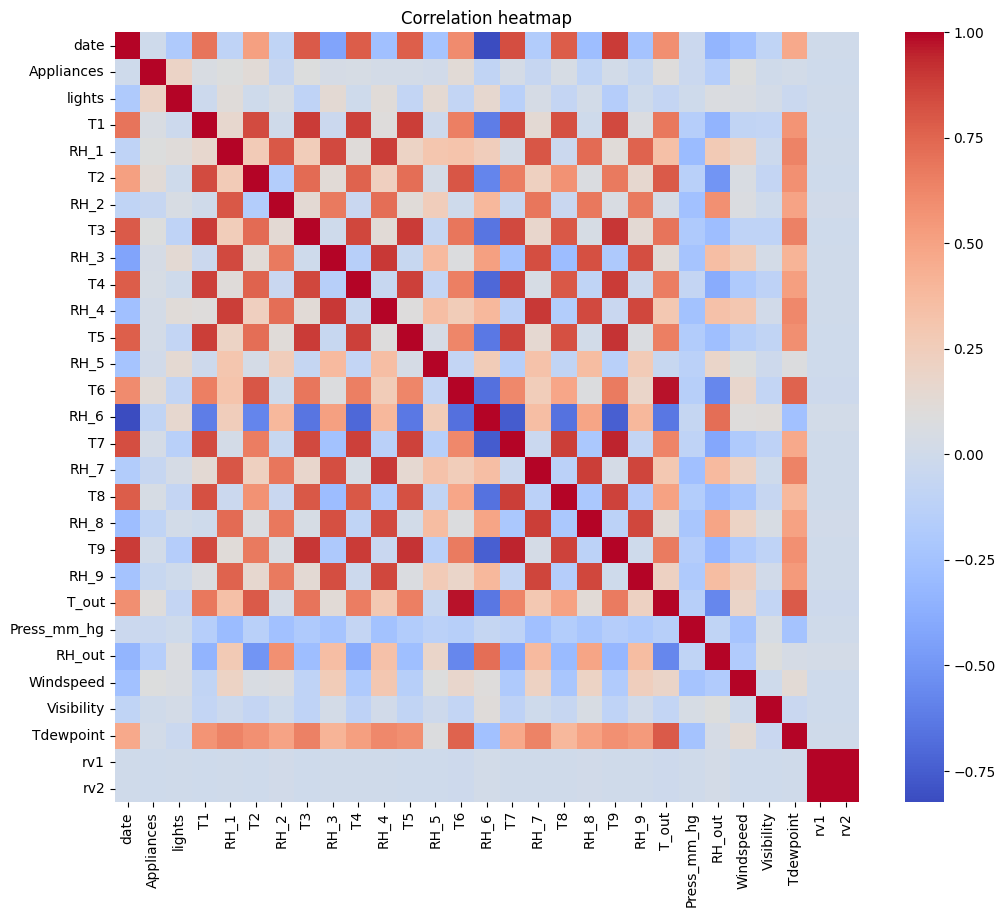

In [12]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

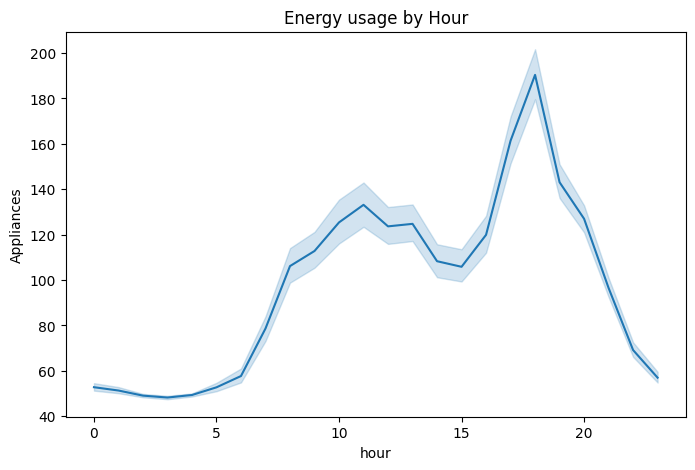

In [13]:
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(8,5))
sns.lineplot(x='hour', y='Appliances', data=df)
plt.title("Energy usage by Hour")
plt.show()

### 2. Feature Engineering

In [ ]:
df['hour'] = df['date'].dt.hour # 0 to 23
df['day_of_month'] = df['date'].dt.day # 1 to 31
df['month'] = df['date'].dt.month # 1=Jan, 5=May
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# time bins
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 0   # morning
    elif 12 <= hour < 18:
        return 1   # afternoon
    elif 18 < hour < 22:
        return 2   # evening
    else:
        return 3   # night

df["time_of_day"] = df["hour"].apply(get_time_of_day)

df['is_morning_peak'] = df['hour'].isin([6, 7, 8, 9, 10, 11]).astype(int)
df['is_evening_peak'] = df['hour'].isin([17, 18, 19, 20, 21]).astype(int)
df['is_night'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

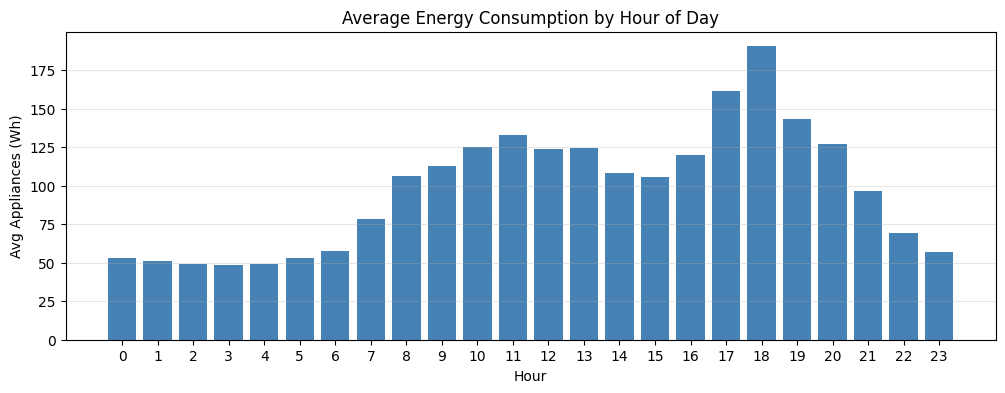

In [15]:
# Visualize Average energy by hour
hourly_avg = df.groupby('hour')['Appliances'].mean()
plt.figure(figsize=(12, 4))
plt.bar(hourly_avg.index, hourly_avg.values, color='steelblue')
plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Appliances (Wh)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()


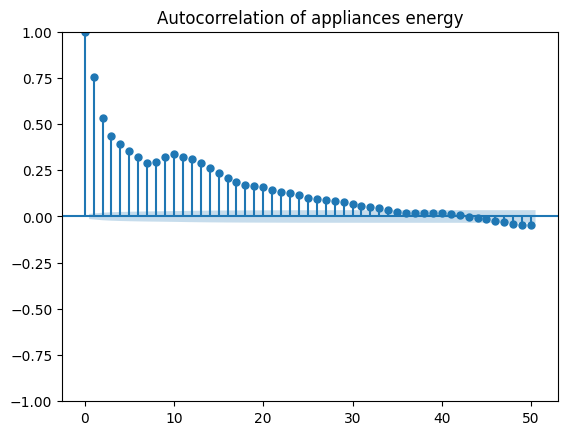

In [16]:
plot_acf(df['Appliances'].dropna(), lags=50)
plt.title("Autocorrelation of appliances energy")
plt.show()

df['lag_1'] = df['Appliances'].shift(1) #10 min
df['lag_3'] = df['Appliances'].shift(3) #30 min
df['lag_6'] = df['Appliances'].shift(6) #1 hr
df['lag_12'] = df['Appliances'].shift(12) #2hr
df['lag_144'] = df['Appliances'].shift(144) #24hr


In [17]:
df['rolling_mean_1h'] = df['Appliances'].shift(1).rolling(window=6).mean()
df['rolling_mean_3h'] = df['Appliances'].shift(1).rolling(window=18).mean()
df['rolling_std_1h'] = df['Appliances'].shift(1).rolling(window=6).std()

In [18]:
df['T_indoor_avg'] = df[['T1', 'T2', 'T3', 'T4', 'T5', 'T6']].mean(axis=1)
df['T_diff'] = df['T_indoor_avg'] - df['T_out']

df['RH_indoor_avg'] = df[['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6']].mean(axis=1)
df['RH_diff'] = df['RH_indoor_avg'] - df['RH_out']

df['T1_RH1'] = df['T1'] * df['RH_1']
df['T_out_RH_out'] = df['T_out'] * df['RH_out']
df['lights_hour'] = df['lights'] * df['hour']



In [19]:
# remove noise features which are known
drop_noise = [col for col in ['rv1', 'rv2'] if col in df.columns]
df = df.drop(columns=drop_noise)

# DROP NaN CREATED BY LAGS/ROLLING
df_clean = df.dropna().reset_index(drop=True)



In [20]:
#save cleaned data
os.makedirs("processed", exist_ok=True)

df_clean.to_csv("processed/energy_data_clean.csv", index=False)

### 3. Preprocessing for Modeling

In [21]:
# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [22]:
split_index = int(0.8 * len(df_clean))

train_df = df_clean.iloc[:split_index].copy()
test_df = df_clean.iloc[split_index:].copy()

X_train_full = train_df.drop(columns=['date', 'Appliances'])
y_train = train_df['Appliances'].copy()

X_test_full = test_df.drop(columns=['date', 'Appliances'])
y_test = test_df['Appliances'].copy()

print("Train shape:", X_train_full.shape, y_train.shape)
print("Test shape:", X_test_full.shape, y_test.shape)

Train shape: (15672, 49) (15672,)
Test shape: (3919, 49) (3919,)


In [23]:
#save train data and test data
train_df.to_csv("processed/train_data.csv", index=False)
test_df.to_csv("processed/test_data.csv", index=False)

In [24]:
# Calculate IQR
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

y_outliers_before = ((y_train < lower_bound) | (y_train > upper_bound)).sum()

print("Number of outliers in y_train before handling:", y_outliers_before)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

y_train = np.clip(y_train, lower_bound, upper_bound)
y_test = np.clip(y_test, lower_bound, upper_bound)



Number of outliers in y_train before handling: 1773
Lower Bound: -25.0
Upper Bound: 175.0


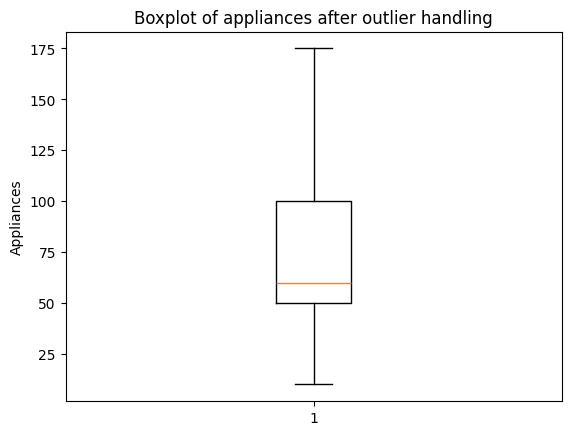

In [25]:
plt.figure()
plt.boxplot(y_train)
plt.title("Boxplot of appliances after outlier handling")
plt.ylabel("Appliances")
plt.show()

In [26]:
# Handle outliers in X features using TRAIN only
feature_bounds = {}

print("Outlier count in each X_train_full feature before and after handling:\n")

for col in X_train_full.columns:
    Q1 = X_train_full[col].quantile(0.25)
    Q3 = X_train_full[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # count before clipping
    outlier_count_before = ((X_train_full[col] < lower) | (X_train_full[col] > upper)).sum()

    feature_bounds[col] = (lower, upper)

    # apply clipping
    X_train_full[col] = X_train_full[col].clip(lower, upper)
    X_test_full[col] = X_test_full[col].clip(lower, upper)

    # count after clipping
    outlier_count_after = ((X_train_full[col] < lower) | (X_train_full[col] > upper)).sum()

    print(f"{col}: before = {outlier_count_before}, after = {outlier_count_after}")

Outlier count in each X_train_full feature before and after handling:

lights: before = 581, after = 0
T1: before = 376, after = 0
RH_1: before = 60, after = 0
T2: before = 99, after = 0
RH_2: before = 49, after = 0
T3: before = 120, after = 0
RH_3: before = 14, after = 0
T4: before = 251, after = 0
RH_4: before = 0, after = 0
T5: before = 0, after = 0
RH_5: before = 1054, after = 0
T6: before = 67, after = 0
RH_6: before = 0, after = 0
T7: before = 0, after = 0
RH_7: before = 82, after = 0
T8: before = 161, after = 0
RH_8: before = 38, after = 0
T9: before = 6, after = 0
RH_9: before = 104, after = 0
T_out: before = 58, after = 0
Press_mm_hg: before = 151, after = 0
RH_out: before = 74, after = 0
Windspeed: before = 45, after = 0
Visibility: before = 2325, after = 0
Tdewpoint: before = 0, after = 0
hour: before = 0, after = 0
day_of_month: before = 0, after = 0
month: before = 0, after = 0
day_of_week: before = 0, after = 0
is_weekend: before = 0, after = 0
time_of_day: before = 0, af

In [27]:
# FEATURE SELECTION (Correlation + RFE on TRAIN ONLY)

# Correlation analysis on TRAIN only
corr_with_target = X_train_full.corrwith(y_train).abs().sort_values(ascending=False)

print("Top 20 features by correlation with target:")
print(corr_with_target.head(20))

# Select top correlated features first
TOP_N_CORR = 20
corr_features = corr_with_target.head(TOP_N_CORR).index.tolist()

print("\nTop correlated features:")
print(corr_features)

# Apply RFE on the shortlisted correlated features
X_train_rfe = X_train_full[corr_features]
X_test_rfe = X_test_full[corr_features]

rfe_model = LinearRegression()
rfe = RFE(estimator=rfe_model, n_features_to_select=10)

rfe.fit(X_train_rfe, y_train)

selected_features = X_train_rfe.columns[rfe.support_].tolist()

print("\nFinal selected features (Correlation + RFE):")
print(selected_features)

# Final selected train/test sets
X_train = X_train_full[selected_features].copy()
X_test = X_test_full[selected_features].copy()

print("\nFinal selected train shape:", X_train.shape)
print("Final selected test shape:", X_test.shape)

Top 20 features by correlation with target:
lag_1              0.845176
rolling_mean_1h    0.739815
lag_3              0.652093
rolling_mean_3h    0.651724
rolling_std_1h     0.629899
lag_6              0.548592
lag_12             0.451097
is_night           0.386747
lag_144            0.382604
hour               0.359727
lights             0.297449
T2                 0.250742
time_of_day        0.229756
T_indoor_avg       0.225134
RH_out             0.211314
RH_diff            0.207757
T3                 0.192106
T6                 0.190913
RH_8               0.190600
T1                 0.188380
dtype: float64

Top correlated features:
['lag_1', 'rolling_mean_1h', 'lag_3', 'rolling_mean_3h', 'rolling_std_1h', 'lag_6', 'lag_12', 'is_night', 'lag_144', 'hour', 'lights', 'T2', 'time_of_day', 'T_indoor_avg', 'RH_out', 'RH_diff', 'T3', 'T6', 'RH_8', 'T1']

Final selected features (Correlation + RFE):
['lag_1', 'is_night', 'hour', 'lights', 'T2', 'time_of_day', 'T_indoor_avg', 'T3', 'T6', '

In [28]:
# Create final selected-features dataset
final_selected_features_data = df_clean[['date', 'Appliances'] + selected_features].copy()

# Save it
final_selected_features_data.to_csv("processed/selected_features_data.csv", index=False)

print("Saved: processed/selected_features_data.csv")

Saved: processed/selected_features_data.csv


In [29]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_X_full = MinMaxScaler()
X_train_full_scaled = scaler_X_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_X_full.transform(X_test_full)

y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1, 1))
y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1))


### 4. Model Development

In [ ]:
lookback = 12

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

lr_pred_scaled = lr_model.predict(X_test_scaled)

y_test_orig = scaler_y.inverse_transform(y_test_scaled).flatten()
lr_pred = scaler_y.inverse_transform(lr_pred_scaled.reshape(-1, 1)).flatten()

y_test_orig_aligned = y_test_orig[lookback:]
lr_pred_aligned = lr_pred[lookback:]

lr_mae = mean_absolute_error(y_test_orig_aligned, lr_pred_aligned)
lr_rmse = np.sqrt(mean_squared_error(y_test_orig_aligned, lr_pred_aligned))
lr_mape = mean_absolute_percentage_error(y_test_orig_aligned, lr_pred_aligned) * 100
lr_r2 = r2_score(y_test_orig_aligned, lr_pred_aligned)

print("Linear Regression")
print(f" MAE  : {lr_mae:.2f} Wh")
print(f" RMSE : {lr_rmse:.2f} Wh")
print(f" MAPE : {lr_mape:.2f} %")
print(f" R²   : {lr_r2:.4f}")

Linear Regression
 MAE  : 14.15 Wh
 RMSE : 21.70 Wh
 MAPE : 19.35 %
 R²   : 0.6813


In [31]:
lookback = 12

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_scaled.ravel())

rf_pred_scaled = rf_model.predict(X_test_scaled)
rf_pred = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1)).flatten()

# Reverse scaling for true test values
y_test_orig = scaler_y.inverse_transform(y_test_scaled).flatten()

# Align with DL evaluation window
y_test_orig_aligned = y_test_orig[lookback:]
rf_pred_aligned = rf_pred[lookback:]

rf_mae = mean_absolute_error(y_test_orig_aligned, rf_pred_aligned)
rf_rmse = np.sqrt(mean_squared_error(y_test_orig_aligned, rf_pred_aligned))
rf_mape = mape_func(y_test_orig_aligned, rf_pred_aligned) * 100
rf_r2 = r2_score(y_test_orig_aligned, rf_pred_aligned)

print("Random Forest")
print(f" MAE  : {rf_mae:.2f} Wh")
print(f" RMSE : {rf_rmse:.2f} Wh")
print(f" MAPE : {rf_mape:.2f} %")
print(f" R²   : {rf_r2:.4f}")


Random Forest
 MAE  : 21.72 Wh
 RMSE : 32.17 Wh
 MAPE : 28.49 %
 R²   : 0.3054


In [32]:
# baseline results to standardize metrics
baseline_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (Wh)': [lr_mae, rf_mae],
    'RMSE (Wh)': [lr_rmse, rf_rmse],
    'MAPE (%)': [lr_mape, rf_mape],
    'R2': [lr_r2, rf_r2]
})

print("\n Baseline Summary ")
print(baseline_results.to_string(index=False))



 Baseline Summary 
            Model  MAE (Wh)  RMSE (Wh)  MAPE (%)       R2
Linear Regression 14.151614  21.701240 19.345570 0.681261
    Random Forest 21.718774  32.168281 28.490245 0.305443


In [33]:
def create_sequences(X, y, lookback=6):
    X_seq, y_seq = [], []

    for i in range(lookback, len(X)):
        # Use exactly X[i] and its recent history up to lookback
        X_seq.append(X[(i - lookback + 1):(i + 1)])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

lookback = 12  # 12 steps = 2 hours of context

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, lookback)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, lookback)

# Align baseline predictions to same window as DL sequences
y_test_orig_seq_baseline = scaler_y.inverse_transform(y_test_scaled[lookback:].reshape(-1, 1)).flatten()

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape :", X_test_seq.shape)
print("y_test_seq shape :", y_test_seq.shape)


X_train_seq shape: (15660, 12, 10)
y_train_seq shape: (15660, 1)
X_test_seq shape : (3907, 12, 10)
y_test_seq shape : (3907, 1)


In [34]:
X_train_lstm = X_train_seq
X_test_lstm = X_test_seq

val_size = int(0.1 * len(X_train_lstm))

X_tr = X_train_lstm[:-val_size]
y_tr = y_train_seq[:-val_size]

X_val = X_train_lstm[-val_size:]
y_val = y_train_seq[-val_size:]

In [35]:
#  MODEL A: LSTM_Model_A

LSTM_Model_A = Sequential([
    LSTM(32, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
], name='LSTM_Model_A')

LSTM_Model_A.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)
LSTM_Model_A.summary()


Model: "LSTM_Model_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# MODEL B: LSTM_Model_B 
def build_model_B(n_features):
    model = Sequential([
        
        LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(0.1), 
        Dense(32, activation='relu'),
        Dense(1)
    ], name='LSTM_Model_B')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mae', metrics=['mae'])
    return model

LSTM_Model_B = build_model_B(X_train_seq.shape[2])
LSTM_Model_B.summary()


Model: "LSTM_Model_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#  MODEL C: CNN_BiLSTM_Attention_Model_C 
# Hybrid CNN-BiLSTM with Simple Attention Head


def build_model_C(n_features):
    inputs = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
    
    # CNN block for local pattern extraction
    x = Conv1D(filters=32, kernel_size=2, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    
    # Bidirectional LSTM for temporal dependencies (return_sequences=True for Attention)
    lstm_out = Bidirectional(LSTM(64, activation='tanh', return_sequences=True))(x)
    
    # SIMPLE ATTENTION HEAD
    # Compute attention weights
    e = Dense(1, activation='tanh')(lstm_out)
    e = Flatten()(e)
    a = Activation('softmax')(e)
    
    # Reshape and Multiply weights by LSTM output
    a = RepeatVector(128)(a) # 128 = 2 * 64 units
    a = Permute([2, 1])(a)
    output_attention = Multiply()([lstm_out, a])
    
    # Sum over time steps to get the context vector
    context_vector = Lambda(lambda x: K.sum(x, axis=1))(output_attention)
    
    # MLP Head
    x = Dense(32, activation='relu')(context_vector)
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='LSTM_Model_C')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mae', metrics=['mae'])
    return model

LSTM_Model_C = build_model_C(X_train_seq.shape[2])
LSTM_Model_C.summary()


Model: "LSTM_Model_C"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 12, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 11, 32)    │        672 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 11, 32)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 11, 128)   │     49,664 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 11, 1)     │        129 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 11)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 11)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 11)   │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 11, 128)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 11, 128)   │          0 │ bidirectional[0]… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      4,128 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,626 (213.38 KB)

 Trainable params: 54,626 (213.38 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# MODEL D: GRU_Model_D 

def build_model_D(n_features):
    model = Sequential([
        GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(0.1), 
        Dense(32, activation='relu'),
        Dense(1)
    ], name='GRU_Model_D')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mae', metrics=['mae'])
    return model

GRU_Model_D = build_model_D(X_train_seq.shape[2])
GRU_Model_D.summary()


Model: "GRU_Model_D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,705 (65.25 KB)

 Trainable params: 16,705 (65.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

EPOCHS = 100
BATCH_SIZE = 64

print("Training LSTM_Model_A")
history_A = LSTM_Model_A.fit(X_tr, y_tr, epochs=10, batch_size=256, validation_data=(X_val, y_val), verbose=0, shuffle=False)

print("\nTraining LSTM_Model_B")
history_B = LSTM_Model_B.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1, shuffle=False)

print("\nTraining LSTM_Model_C")
history_C = LSTM_Model_C.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stop, reduce_lr], verbose=1, shuffle=False)

print("\nTraining GRU_Model_D")
history_D = GRU_Model_D.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1, shuffle=False)



Training LSTM_Model_A

Training LSTM_Model_B
Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1335 - mae: 0.1335 - val_loss: 0.1026 - val_mae: 0.1026
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1099 - mae: 0.1099 - val_loss: 0.0947 - val_mae: 0.0947
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1000 - mae: 0.1000 - val_loss: 0.0831 - val_mae: 0.0831
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0925 - mae: 0.0925 - val_loss: 0.0788 - val_mae: 0.0788
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0898 - mae: 0.0898 - val_loss: 0.0799 - val_mae: 0.0799
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0884 - mae: 0.0884 - val_loss: 0.0777 - val_mae: 0.0777
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0875 - mae: 0.0875 - val_loss: 0.0769 - val_mae: 0.0769
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0880 - mae: 0.0880 - val_loss: 0.0767 - val_mae: 0.0767
Epo

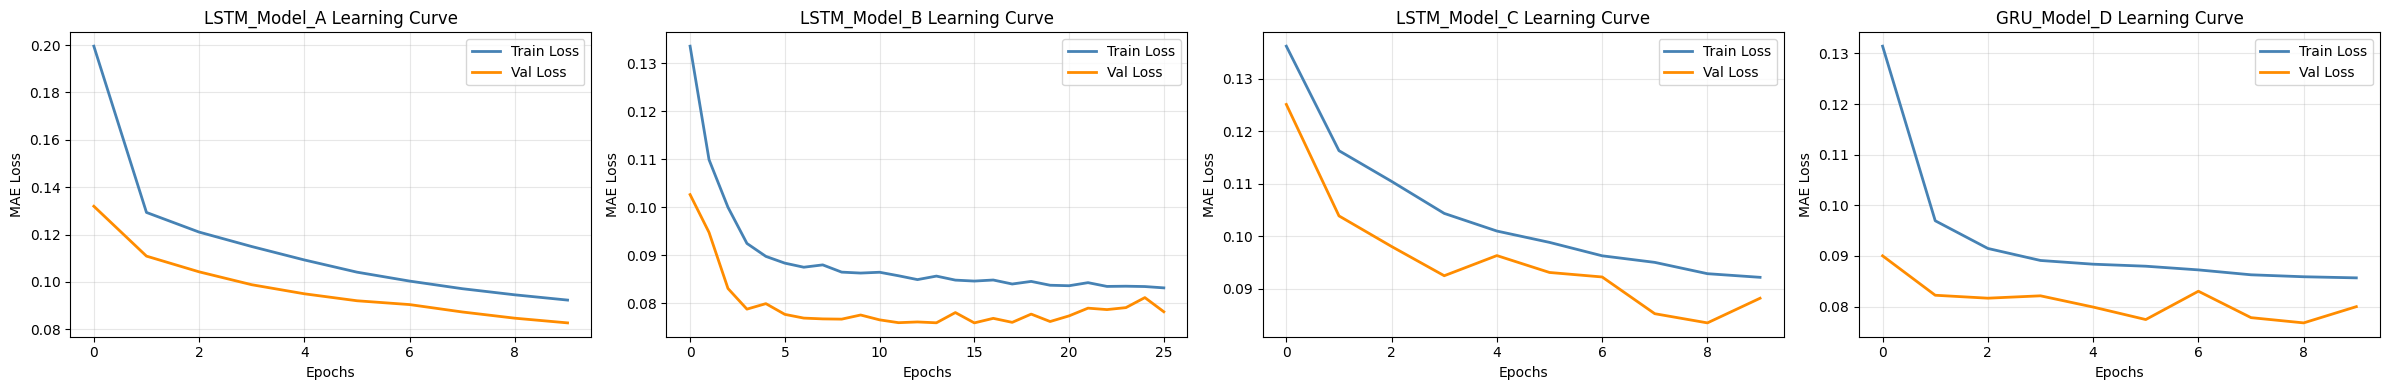

In [40]:
# PLOT TRAINING HISTORY
fig, axes = plt.subplots(1, 4, figsize=(24, 4))

histories = [
    (history_A, 'LSTM_Model_A'),
    (history_B, 'LSTM_Model_B'),
    (history_C, 'LSTM_Model_C'),
    (history_D, 'GRU_Model_D')
]

for ax, (history, name) in zip(axes, histories):
    ax.plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss', color='darkorange', linewidth=2)
    ax.set_title(f'{name} Learning Curve')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('MAE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    
plt.tight_layout()
plt.show()


In [41]:
# EVALUATE ALL MODELS 
APPLIANCES_STD = y_train.std()

def evaluate_model(model, X_test, y_test, scaler):
    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mape = mape_func(y_true, pred) * 100
    r2 = r2_score(y_true, pred)
    return pred, y_true, mae, rmse, mape, r2

initial_dl_models = [
    (LSTM_Model_A, 'LSTM_Model_A'),
    (LSTM_Model_B, 'LSTM_Model_B'),
    (LSTM_Model_C, 'LSTM_Model_C'),
    (GRU_Model_D,  'GRU_Model_D')
]

preds_dict = {}
dl_results = []

for mod, name in initial_dl_models:
    pred, y_true, mae, rmse, mape, r2 = evaluate_model(mod, X_test_lstm, y_test_seq, scaler_y)
    preds_dict[name] = pred
    mae_z = mae / APPLIANCES_STD
    rmse_z = rmse / APPLIANCES_STD
    dl_results.append({
        'Model': name, 
        'MAE (Wh)': mae, 
        'RMSE (Wh)': rmse, 
        'MAPE (%)': mape, 
        'MAE (Z)': mae_z, 
        'RMSE (Z)': rmse_z, 
        'R2': r2
    })

dl_results_df = pd.DataFrame(dl_results)
display(dl_results_df.round(4))

best_dl_model_row = dl_results_df.loc[dl_results_df['MAE (Wh)'].idxmin()]
best_model_name = best_dl_model_row['Model']
print(f"\n BEST MODEL SELECTED FOR OPTIMIZATION: {best_model_name} ")
results_df = dl_results_df.copy() 


,Model,MAE (Wh),RMSE (Wh),MAPE (%),MAE (Z),RMSE (Z),R2
0,LSTM_Model_A,13.0876,21.7601,16.3928,0.2981,0.4956,0.6822
1,LSTM_Model_B,12.4266,21.7288,15.8039,0.2830,0.4949,0.6831
2,LSTM_Model_C,19.0102,29.9137,20.0914,0.4330,0.6814,0.3994
3,GRU_Model_D,15.6340,24.2058,17.6772,0.3561,0.5513,0.6067



 BEST MODEL SELECTED FOR OPTIMIZATION: LSTM_Model_B 


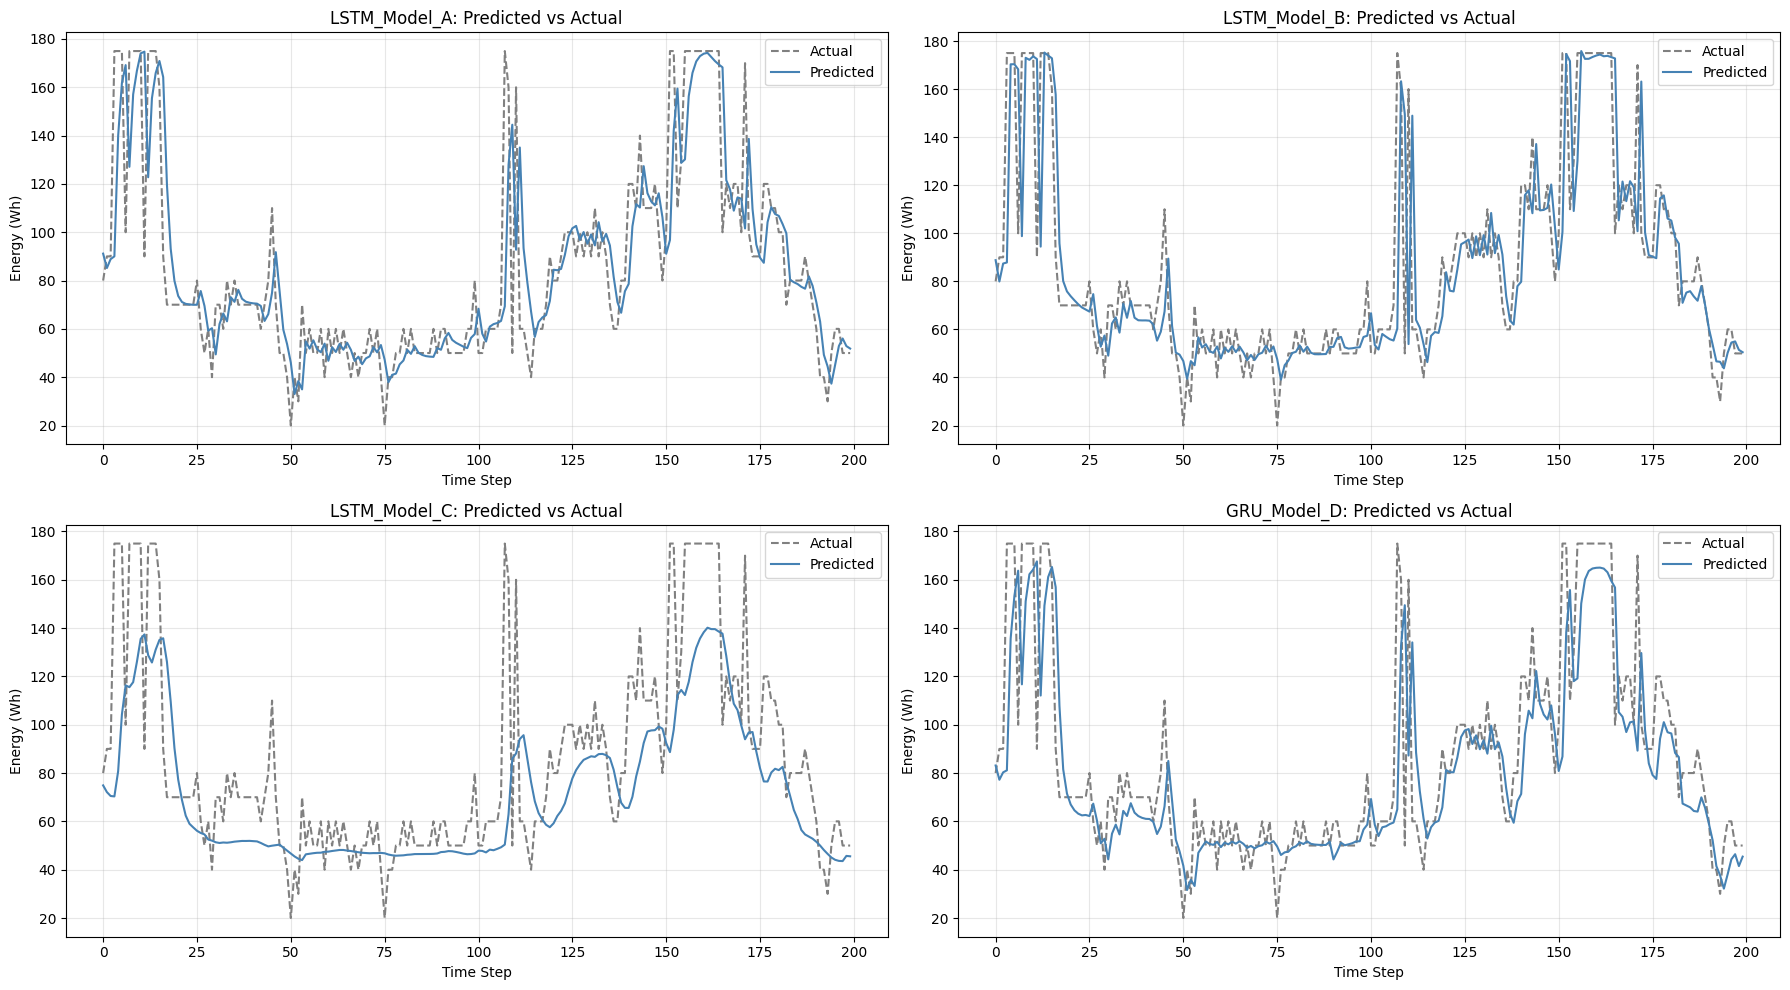

In [42]:
# VISUALIZATION 1: Predicted vs Actual

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, (mod, name) in enumerate(initial_dl_models):
    pred = preds_dict[name]
    time_axis = np.arange(len(y_true))[:200]  # Plot first 200 points for clarity
    axes[i].plot(time_axis, y_true[:200], label='Actual', color='gray', linestyle='--')
    axes[i].plot(time_axis, pred[:200], label='Predicted', color='steelblue')
    axes[i].set_title(f'{name}: Predicted vs Actual')
    axes[i].set_ylabel('Energy (Wh)')
    axes[i].set_xlabel('Time Step')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


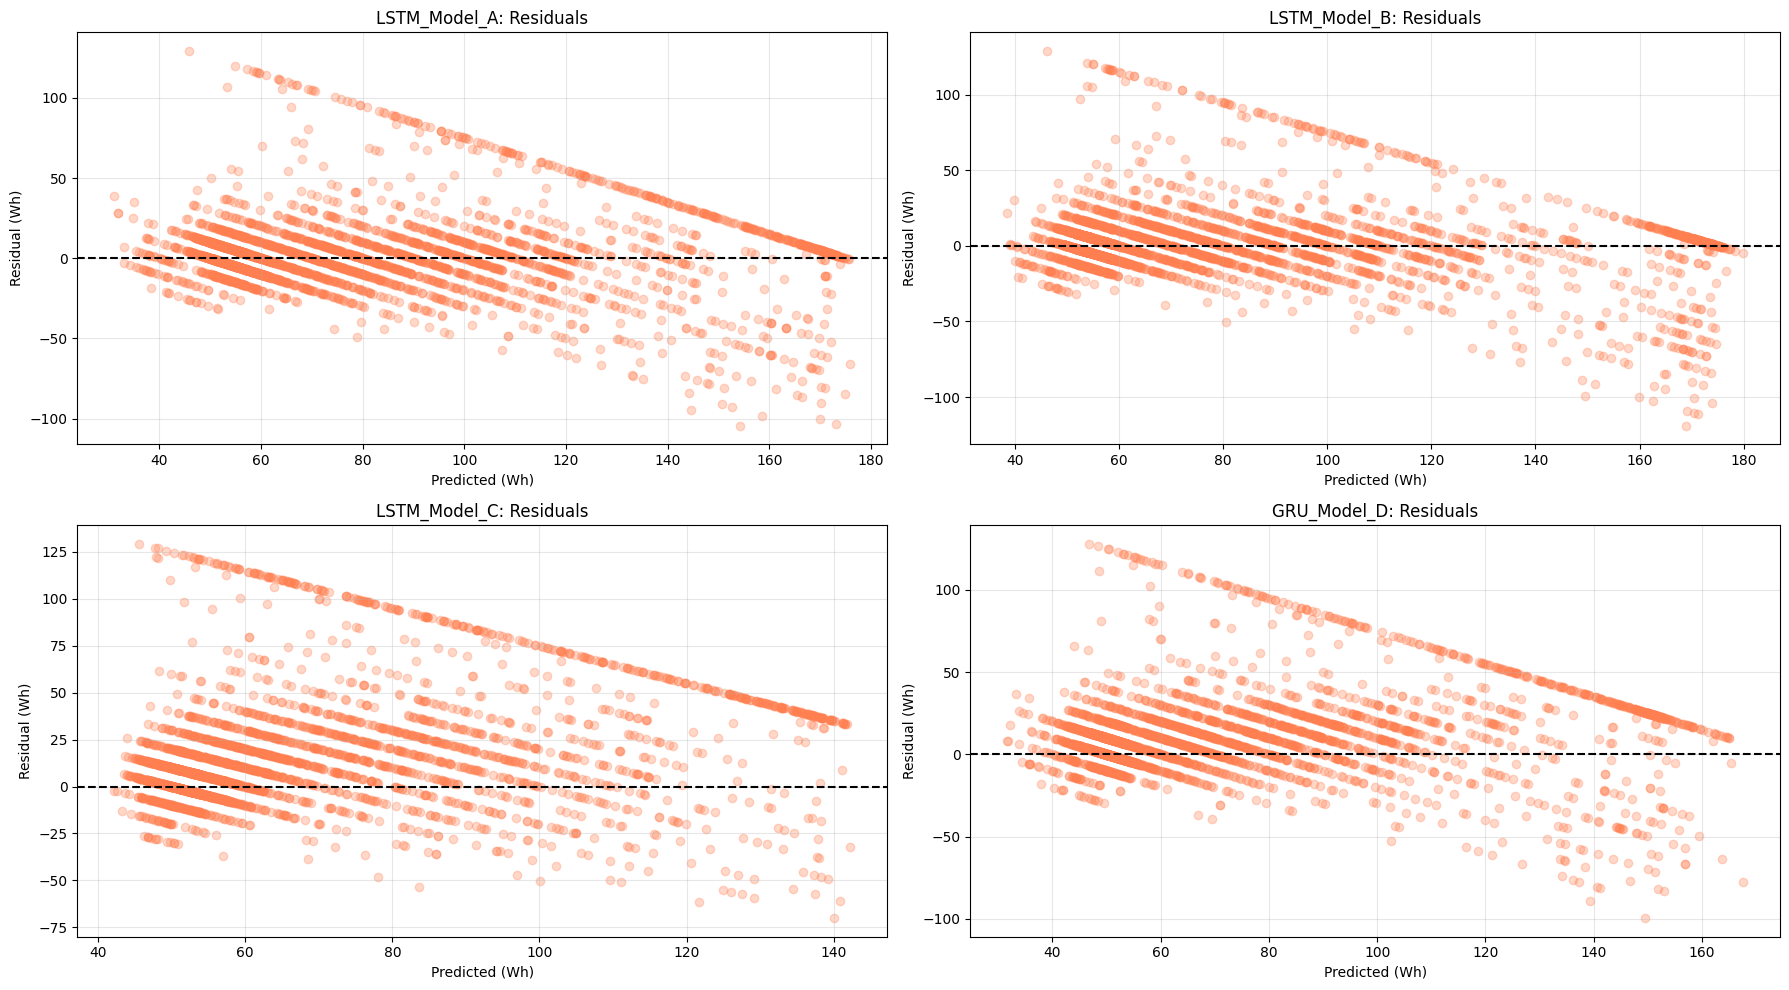

In [43]:
# VISUALIZATION 2: Residual Plots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, (mod, name) in enumerate(initial_dl_models):
    pred = preds_dict[name]
    residuals = y_true - pred
    axes[i].scatter(pred, residuals, alpha=0.3, color='coral')
    axes[i].axhline(y=0, color='black', linestyle='--')
    axes[i].set_title(f'{name}: Residuals')
    axes[i].set_xlabel('Predicted (Wh)')
    axes[i].set_ylabel('Residual (Wh)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


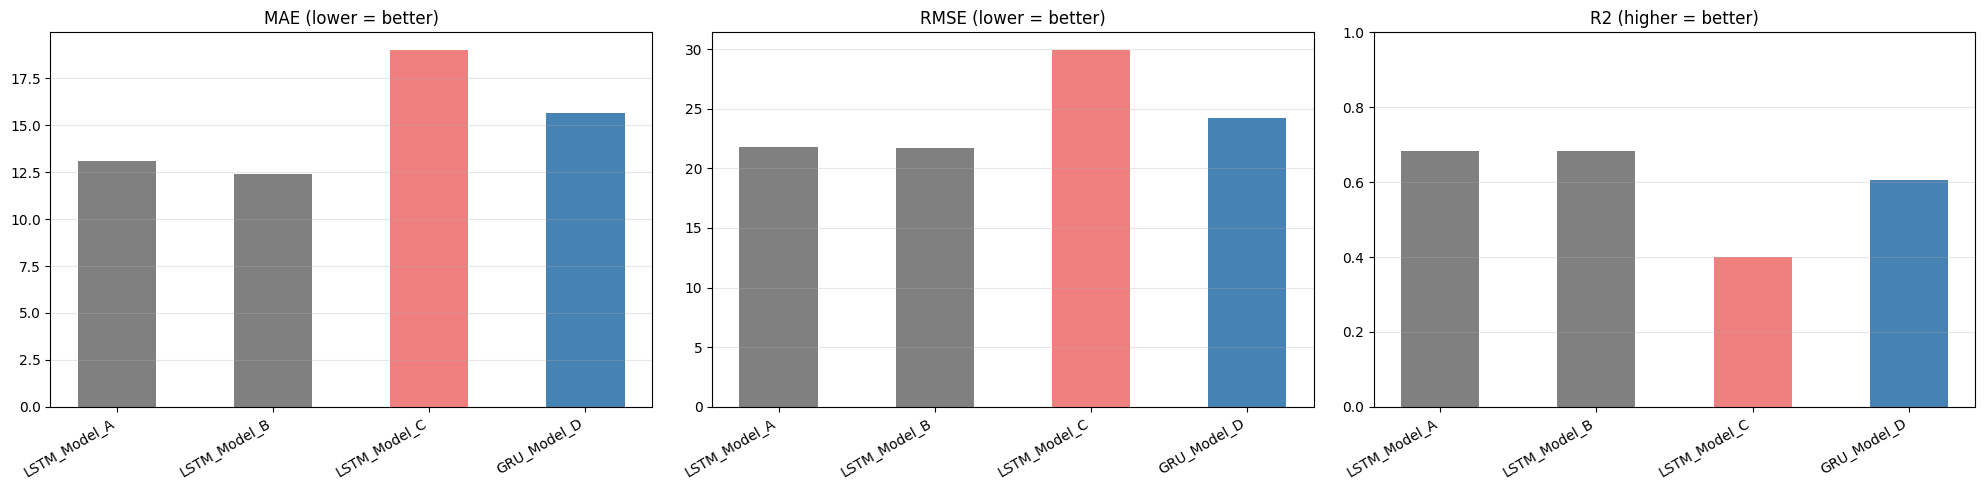

In [44]:
# VISUALIZATION 3: Bar Chart of Evaluation Metrics

models = results_df['Model'].tolist()
mae_vals = results_df['MAE (Wh)'].tolist()
rmse_vals = results_df['RMSE (Wh)'].tolist()
r2_vals = results_df['R2'].tolist()

x = np.arange(len(models))
colors = ['gray', 'gray', 'lightcoral', 'steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(x, mae_vals, width=0.5, color=colors)
axes[0].set_title('MAE (lower = better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=30, ha='right')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, rmse_vals, width=0.5, color=colors)
axes[1].set_title('RMSE (lower = better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(x, r2_vals, width=0.5, color=colors)
axes[2].set_title('R2 (higher = better)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=30, ha='right')
axes[2].set_ylim(0, 1) # R2 scale
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Model Optimization

In [45]:
# HYPERPARAMETER OPTIMIZATION FOR LSTM_Model_B 

print(f"Optimizing {best_model_name}")

# Only continue if the selected best model is LSTM_Model_B
if best_model_name != 'LSTM_Model_B':
    print(f"Warning: best_model_name is {best_model_name}, but this tuner is designed for LSTM_Model_B only.")

def build_lstm_b_candidate(units, n_layers, lr, dropout_rate):
    model = Sequential(name='Optimized_LSTM_Model_B')

    # Single-layer version
    if n_layers == 1:
        model.add(
            LSTM(
                units,
                input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
                kernel_regularizer=l2(0.001)
            )
        )
        model.add(Dropout(dropout_rate))

    # Two-layer version
    elif n_layers == 2:
        model.add(
            LSTM(
                units,
                return_sequences=True,
                input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
                kernel_regularizer=l2(0.001)
            )
        )
        model.add(Dropout(dropout_rate))

        model.add(
            LSTM(
                units // 2,
                kernel_regularizer=l2(0.001)
            )
        )
        model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mae',
        metrics=['mae']
    )
    return model

# Search space 
param_grid = {
    "units": [64, 128],
    "n_layers": [1, 2],
    "lr": [0.001, 0.0005],
    "dropout_rate": [0.1, 0.2, 0.3],
    "batch_size": [16, 32]
}

keys, values = zip(*param_grid.items())
all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

random.seed(42)
sampled_params = random.sample(all_combinations, min(len(all_combinations), 10))

# Add baseline-like configuration if missing
baseline_p = {
    'units': 64,
    'n_layers': 1,
    'lr': 0.001,
    'dropout_rate': 0.1,
    'batch_size': 32
}
if baseline_p not in sampled_params:
    sampled_params.append(baseline_p)

tuning_results = []

early_stop_tuning = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

for i, params in enumerate(sampled_params):
    print(f"\nTesting Candidate {i+1}/{len(sampled_params)}: {params}")

    cand_model = build_lstm_b_candidate(
        units=params['units'],
        n_layers=params['n_layers'],
        lr=params['lr'],
        dropout_rate=params['dropout_rate']
    )

    cand_model.fit(
        X_tr, y_tr,
        epochs=30,
        batch_size=params['batch_size'],
        validation_data=(X_val, y_val),
        callbacks=[early_stop_tuning],
        verbose=0,
        shuffle=False
    )

    val_pred_scaled = cand_model.predict(X_val, verbose=0)
    val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten()
    val_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()

    val_mae = mean_absolute_error(val_true, val_pred)
    val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))

    tuning_results.append({
        **params,
        'val_mae': val_mae,
        'val_rmse': val_rmse
    })

search_df = pd.DataFrame(tuning_results).sort_values(by=['val_mae', 'val_rmse'])
display(search_df)


Optimizing LSTM_Model_B

Testing Candidate 1/10: {'units': 128, 'n_layers': 2, 'lr': 0.001, 'dropout_rate': 0.3, 'batch_size': 16}

Testing Candidate 2/10: {'units': 64, 'n_layers': 1, 'lr': 0.0005, 'dropout_rate': 0.1, 'batch_size': 32}

Testing Candidate 3/10: {'units': 64, 'n_layers': 1, 'lr': 0.001, 'dropout_rate': 0.1, 'batch_size': 32}

Testing Candidate 4/10: {'units': 64, 'n_layers': 2, 'lr': 0.001, 'dropout_rate': 0.3, 'batch_size': 32}

Testing Candidate 5/10: {'units': 64, 'n_layers': 2, 'lr': 0.001, 'dropout_rate': 0.2, 'batch_size': 32}

Testing Candidate 6/10: {'units': 64, 'n_layers': 2, 'lr': 0.001, 'dropout_rate': 0.2, 'batch_size': 16}

Testing Candidate 7/10: {'units': 64, 'n_layers': 1, 'lr': 0.0005, 'dropout_rate': 0.2, 'batch_size': 16}

Testing Candidate 8/10: {'units': 64, 'n_layers': 1, 'lr': 0.0005, 'dropout_rate': 0.1, 'batch_size': 16}

Testing Candidate 9/10: {'units': 128, 'n_layers': 1, 'lr': 0.0005, 'dropout_rate': 0.3, 'batch_size': 16}

Testing Candida

,units,n_layers,lr,dropout_rate,batch_size,val_mae,val_rmse
1,64,1,0.0005,0.1,32,12.494732,21.090638
0,128,2,0.0010,0.3,16,13.631719,21.664163
8,128,1,0.0005,0.3,16,17.559128,26.682286
7,64,1,0.0005,0.1,16,17.612665,26.500237
2,64,1,0.0010,0.1,32,17.679736,26.673097
6,64,1,0.0005,0.2,16,17.941296,27.417823
9,64,1,0.0010,0.3,32,20.891588,29.919657
5,64,2,0.0010,0.2,16,21.710326,33.119584
4,64,2,0.0010,0.2,32,23.103513,34.151591
3,64,2,0.0010,0.3,32,25.250598,37.029711


In [46]:
# best hyperparameters
best_params = search_df.iloc[0].to_dict()
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'units': 64.0, 'n_layers': 1.0, 'lr': 0.0005, 'dropout_rate': 0.1, 'batch_size': 32.0, 'val_mae': 12.494731817817932, 'val_rmse': 21.090637915477107}


In [47]:
# build final optimized LSTM_Model_B

best_p = search_df.iloc[0].to_dict()

optimized_model = build_lstm_b_candidate(
    units=int(best_p['units']),
    n_layers=int(best_p['n_layers']),
    lr=float(best_p['lr']),
    dropout_rate=float(best_p['dropout_rate'])
)

optimized_model._name = 'Optimized_LSTM_Model_B'

early_stop_opt = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_opt = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

print('Training Optimized LSTM_Model_B')
history_opt = optimized_model.fit(
    X_tr, y_tr,
    epochs=300,
    batch_size=int(best_p['batch_size']),
    validation_data=(X_val, y_val),
    callbacks=[early_stop_opt, reduce_lr_opt],
    verbose=1,
    shuffle=False
)

Training Optimized LSTM_Model_B
Epoch 1/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1550 - mae: 0.1398 - val_loss: 0.1171 - val_mae: 0.1051 - learning_rate: 5.0000e-04
Epoch 2/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1237 - mae: 0.1135 - val_loss: 0.1062 - val_mae: 0.0974 - learning_rate: 5.0000e-04
Epoch 3/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1116 - mae: 0.1037 - val_loss: 0.0968 - val_mae: 0.0897 - learning_rate: 5.0000e-04
Epoch 4/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1039 - mae: 0.0973 - val_loss: 0.0929 - val_mae: 0.0868 - learning_rate: 5.0000e-04
Epoch 5/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0981 - mae: 0.0922 - val_loss: 0.0872 - val_mae: 0.0818 - learning_rate: 5.0000e-04
Epoch 6/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0950 - mae: 0.0899 - val_loss: 0.0877 - val_mae: 0.0830 - learning_rate: 5.0000e-04
Epoch 7/300
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0932 - mae: 0.0887 - va

In [54]:
# post optimization evaluation of the tuned model

opt_pred_scaled = optimized_model.predict(X_test_lstm, verbose=0).flatten()
y_test_orig_seq = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
pred_opt = scaler_y.inverse_transform(opt_pred_scaled.reshape(-1, 1)).flatten()

mae_opt = mean_absolute_error(y_test_orig_seq, pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test_orig_seq, pred_opt))
mape_opt = mape_func(y_test_orig_seq, pred_opt) * 100
r2_opt = r2_score(y_test_orig_seq, pred_opt)

print(f'Final MAE (Wh): {mae_opt:.2f}')
print(f'Final RMSE (Wh): {rmse_opt:.2f}')
print(f'Final MAPE (%): {mape_opt:.2f}')
print(f'Final R²: {r2_opt:.4f}')

y_actual = y_test_orig_seq

Final MAE (Wh): 12.04
Final RMSE (Wh): 21.50
Final MAPE (%): 15.53
Final R²: 0.6899


In [55]:
# PERFORMANCE COMPARISON WITH BASELINE LSTM_Model_B

best_row = dl_results_df[dl_results_df['Model'] == 'LSTM_Model_B'].iloc[0]

print("\nFINAL REPORT: Optimized LSTM_Model_B Performance")
print(f"  RAW MAE   : {mae_opt:.2f} Wh")
print(f"  RAW RMSE  : {rmse_opt:.2f} Wh")
print(f"  RAW MAPE  : {mape_opt:.2f}%")
print(f"  R² SCORE  : {r2_opt:.4f}")

diff_df = pd.DataFrame({
    'Stage': ['Baseline (LSTM_Model_B)', 'Optimized model'],
    'MAE (Wh)': [best_row['MAE (Wh)'], mae_opt],
    'RMSE (Wh)': [best_row['RMSE (Wh)'], rmse_opt],
    'MAPE (%)': [best_row['MAPE (%)'], mape_opt],
    'R2': [best_row['R2'], r2_opt]
})
display(diff_df.round(4))


FINAL REPORT: Optimized LSTM_Model_B Performance
  RAW MAE   : 12.04 Wh
  RAW RMSE  : 21.50 Wh
  RAW MAPE  : 15.53%
  R² SCORE  : 0.6899


,Stage,MAE (Wh),RMSE (Wh),MAPE (%),R2
0,Baseline (LSTM_Model_B),12.4266,21.7288,15.8039,0.6831
1,Optimized model,12.0368,21.4959,15.5272,0.6899


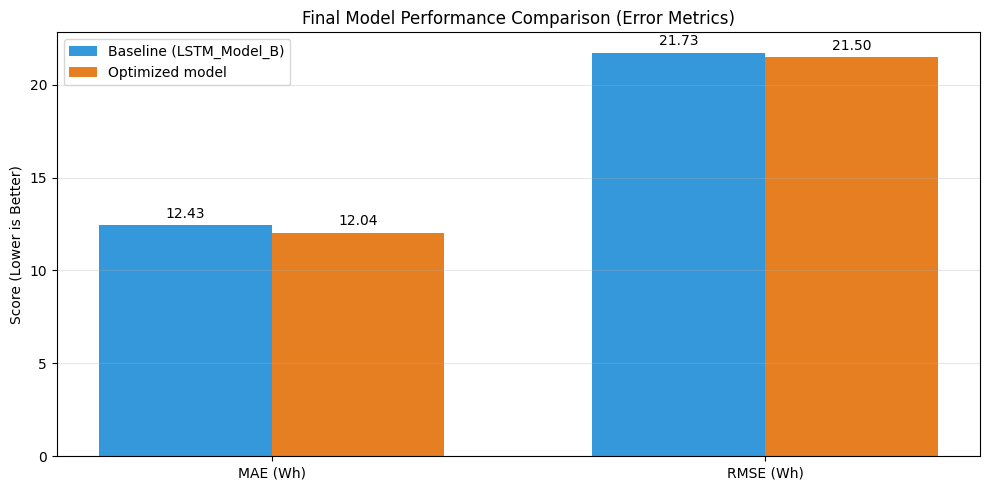

In [56]:
# Visualization of Performance comparison with baseline model (Before vs After)

metrics_labels = ['MAE (Wh)', 'RMSE (Wh)']
baseline_scores = [best_row['MAE (Wh)'], best_row['RMSE (Wh)']]
optimized_scores = [mae_opt, rmse_opt]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, baseline_scores,  width, label=f'Baseline ({best_model_name})', color='#3498db')
rects2 = ax.bar(x + width/2, optimized_scores, width, label='Optimized model', color='#e67e22')

ax.set_ylabel('Score (Lower is Better)')
ax.set_title('Final Model Performance Comparison (Error Metrics)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add text labels above the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height), 
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()


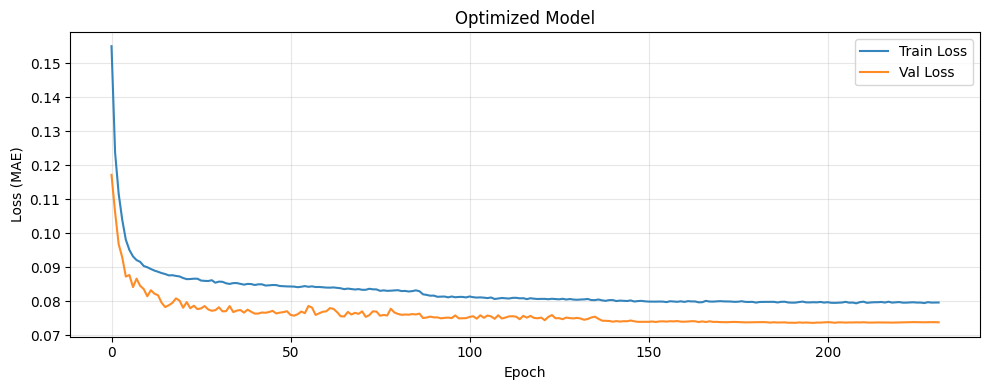

In [57]:
# Plot: Optimized model training history 

plt.figure(figsize=(10, 4))
plt.plot(history_opt.history['loss'], label='Train Loss', alpha=0.9)
if 'val_loss' in history_opt.history: 
    plt.plot(history_opt.history['val_loss'], label='Val Loss', alpha=0.9)

plt.title('Optimized Model')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


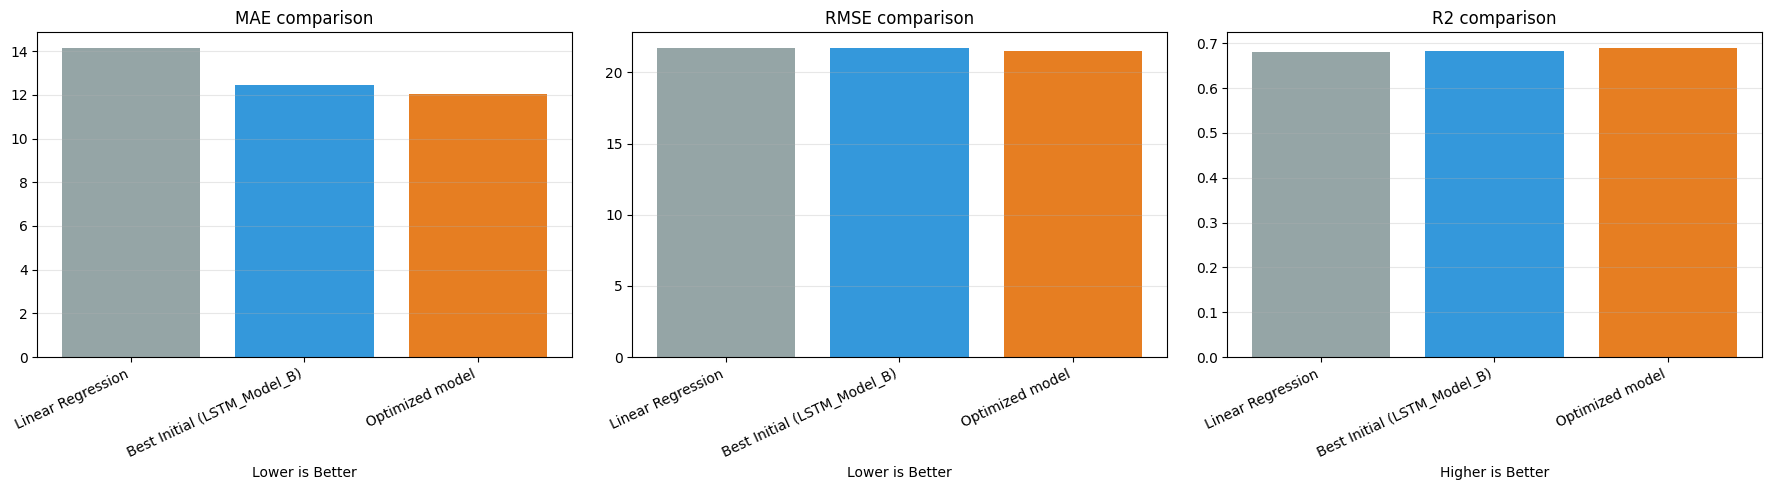

In [58]:
# FINAL PERFORMANCE COMPARISON

best_init_row = results_df[results_df['Model'] == best_model_name].iloc[0]

viz_models = ['Linear Regression', f'Best Initial ({best_model_name})', 'Optimized model']
viz_mae = [lr_mae,  best_init_row['MAE (Wh)'],  mae_opt]
viz_rmse = [lr_rmse, best_init_row['RMSE (Wh)'], rmse_opt]
viz_r2 = [lr_r2,   best_init_row['R2'],        r2_opt]

x = np.arange(len(viz_models))
colors = ['#95a5a6', '#3498db', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplots for MAE, RMSE, R2
metrics = [(viz_mae, 'MAE comparison', 'Lower is Better'), 
           (viz_rmse, 'RMSE comparison', 'Lower is Better'), 
           (viz_r2, 'R2 comparison', 'Higher is Better')]

for i, (data, title, sub) in enumerate(metrics):
    axes[i].bar(x, data, color=colors)
    axes[i].set_title(title)
    axes[i].set_xlabel(sub)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(viz_models, rotation=25, ha='right')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()




In [59]:
# Save model
optimized_model.save('trained_model.h5')
print('Model successfully saved.')

Model successfully saved.
